# v01

In v01 I will modularize, and do downsampling

# v02
Move modules into another library and import it

# v03
More robust, longer slice av

# the problem

The goal is to estimate an atlas $I$ that matches slices $J$ with transformations $R$.

Minimize 
\begin{align}
f[( R_i\cdot I_i - J_i )^2] + \frac{k}{2} \|LI\|^2
\end{align}

Where $f$ is some robust loss.

We do this in 2 steps.  First we update the rigid parameters.  Then we convert to weighted least squares and update the atlas.

Let $f(x) = cx / (x + c)$.  Note that for large $x$ this function approaches the constant $c$.  And for small $x$ it approaches the function $x$.  So it's like a normal quadratic function for small error, but flattens out to some maximum for large error.

Note this function $f$ is always overestimated by a linear tangent.

# majorization
Let $g(x|x^{(k)})$ majorize $f$ at the current guess $x^{(x)}$.  We can do a taylor expansion.


$f(x^{(k)}) = cx^{(k)}/(x^{(k)} + c)$

$f'(x^{(k)}) = \frac{c(x^{(k)}+c) - cx^{(k)}}{(x^{(k)}+c)^2} = \frac{c^2}{(x^{(k)} + c)^2}$ 


So $g(x|x^{(k)}) = cx^{(k)}/(x^{(k)} + c) + (x-x^{(k)})\frac{c^2}{(x^{(k)} + c)^2}$

Minimizing this is equivalent to minimizing
\begin{align}
h(x|x^{(k)}) = x\frac{c^2}{(x^{(k)} + c)^2}
\end{align}
Since $x$ is square error, we can define the term on the right as a weight $W = \frac{c^2}{(x^{(k)} + c)^2}$

# updating the atlas
At each iteration we have
\begin{align}
&\|R\cdot I - J\|^2_{W} + \frac{k}{2}\|LI\|^2 \\
&= | I - R^{-1}\cdot J\|^2_{R^{-1}\cdot W}+ \frac{k}{2}\|LI\|^2 
\end{align}

We want to majorize it again.  But this one is relatively straight forward.  We use $W_{\text{max}}$ instead of $W(x)$.


$( id + \frac{k}{2W_{\text{max}}}LL)I = R^{-1}\cdot J (R^{-1}\cdot W / W_{\text{max}}) + I^{(k)} (1 - R^{-1}\cdot W / W_{\text{max}})$

The left side can be inverted in the Fourier domain.

# Todo
Make the domain of the atlas bigger.

# import

In [1]:
import numpy as np
from glob import glob
from os.path import join
import matplotlib.pyplot as plt
%matplotlib widget

import tifffile
import sys
#sys.path.append('/home/daniel/Documents/shadowing/emlddmm')
#import emlddmm

from scipy.interpolate import interpn
from scipy.ndimage import gaussian_filter

import torch

from scipy.ndimage import gaussian_filter

from importlib import reload
import atlas_free_alignment as afa

# load a dataset

zebrafinch

/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/

/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1024_converted/


octopus: /nfs/data/main/M25/mba_converted_imaging_data/MD685\&684/

In [2]:
directory = '/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025'

In [3]:
ndown = 2
dx = 0.46*32
dz = 20
dz = 40


In [4]:
files = glob(join(directory,'*.tif'))

In [5]:
def key(x):
    return int( x.split('_')[-1].split('.')[0] )
    

In [6]:
files.sort(key=key)
files

['/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025/MD1025-N1-2025.11.03-19.06.38_MD1025_1_0001.tif',
 '/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025/MD1025-N1-2025.11.03-19.06.38_MD1025_2_0002.tif',
 '/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025/MD1025-N2-2025.11.03-19.12.24_MD1025_1_0003.tif',
 '/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025/MD1025-N2-2025.11.03-19.12.24_MD1025_2_0004.tif',
 '/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025/MD1025-N3-2025.11.03-19.19.57_MD1025_1_0005.tif',
 '/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025/MD1025-N3-2025.11.03-19.19.57_MD1025_2_0006.tif',
 '/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025/MD1025-N4-2025.11.03-19.26.12_MD1025_1_0007.tif',
 '/nfs/data/qc/qcdisk006/mba_converted_imaging_data/MD1025_converted/MD1025/MD1025-N4-2025.11.03-19.26.12_MD1025_2_000

In [7]:
# get the numbers
locations = np.array( [key(f) for f in files] )
all_locations = np.arange(np.min(locations),np.max(locations)+1)
good_locations = [a in locations for a in all_locations]

In [8]:
len(locations)

273

In [9]:
reload(afa)

<module 'atlas_free_alignment' from '/nfs/data/main/M38/Atlas_free_alignment/atlas_free_alignment.py'>

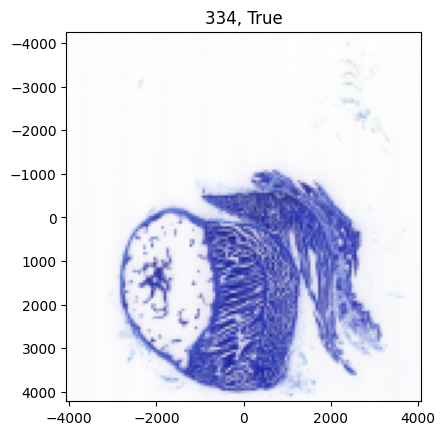

/nfs/data/main/M38/Atlas_free_alignment/atlas_free_alignment.py:294: RuntimeWarning: invalid value encountered in divide
  Id = Id / (Wd + Wd.max()*1e-6)


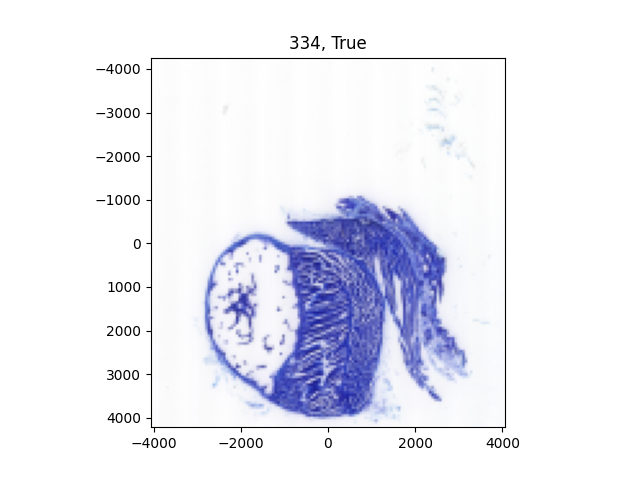

In [10]:

fig,ax = plt.subplots()
hfig = display(fig,display_id=True)
J_ = []
W_ = []
xJ_ = []
nJ_ = []

count = 0


for i in range(len(all_locations)):
    if good_locations[i]:
        Ji = tifffile.imread(files[count])
        if Ji.dtype == np.uint8:
            Ji = Ji/255.0
        #Wi = np.ones_like(Ji[...,0])
        # check for rows or cols of 1s
        # this W variable will be 0 where pixels are bad, and 1 where pixels are good
        #Wi = np.logical_not( (np.all(Ji==1.0,axis=(0,-1),keepdims=True) + np.all(Ji==1.0,axis=(1,-1),keepdims=True)))[...,0]*1.0
        Wi = 1-np.all(Ji==1.0,axis=-1)
        # AND
        # take the first 100 rows
        #Wi[:150] = 0
        
        
        count += 1
    else: # just fill it with something small
        Ji = np.zeros((11,11,3))
        Wi = np.zeros((11,11))
        
    nJi = np.array(Wi.shape)
    xJi = [np.arange(n)*dx - (n-1)*dx/2 for n in nJi]
    # downsample the dataset so it is about 50 microns    
    xJi,Ji,Wi = afa.downsample_image_domain(xJi,Ji.transpose(-1,0,1),[2**ndown]*2,Wi)
    
    nJi = np.array(Wi.shape)
    Wi[np.isnan(Wi)] = 0
    Ji[np.isnan(Ji)] = 1

    # normalize the data, such that the brightest pixel is white
    try:
        q = np.quantile(Ji[:,Wi==1],0.99,axis=(1))
        Ji = Ji / q[...,None,None]
        Ji = Ji.clip(0,1)
    except:
        pass

    nJ_.append(nJi)    
    xJ_.append(xJi)
    J_.append(Ji)
    W_.append(Wi)

    
    ax.cla()
    ax.imshow((Ji*Wi).transpose(1,2,0),extent=afa.extent_from_x(xJi))
    ax.set_title(f'{i}, {good_locations[i]}')
    fig.canvas.draw()
    hfig.update(fig)
        

        

In [11]:
len(J_),len(all_locations)

(335, 335)

In [13]:
# now put into a volume

# find a size and interpolate images to this fixed size
q = np.ceil(np.quantile(nJ_,[0.95],0)).astype(int)
q = np.ceil(np.quantile(nJ_,[0.95],0)*1.5).astype(int)
# I think I want it to be bigger! TODO


nJ = np.concatenate([[len(all_locations)],q.squeeze()])
dJ = np.array([dz,dx*2**ndown,dx*2**ndown])
xJ = [np.arange(n)*d - (n-1)*d/2 for n,d in zip(nJ,dJ)]
XJ2d = np.stack(np.meshgrid(*xJ[1:],indexing='ij'),-1)
J__ = []
W__ = []
A2d0 = np.eye(3)[None].repeat(len(J_),axis=0)
for i in range(len(J_)):
    # update A2d based on COM?

    Jb = gaussian_filter(J_[i],sigma=(0,5,5))    
    #Wb = gaussian_filter(W_[i],sigma=(5,5))
    Wb = W_[i]
    Jb = 1-np.mean(Jb,0)
    Jb0 = np.sum(Jb*Wb)
    Jb10 = np.sum( Jb*Wb*xJ_[i][0][:,None] )
    Jb11 = np.sum(Jb*Wb*xJ_[i][1])
    com = [Jb10/Jb0, Jb11/Jb0]
    A2d0[i][:2,-1] = com
    Xs = (A2d0[i][:2,:2]@XJ2d[...,None])[...,0] + A2d0[i][:2,-1]     # not using this for resampling the image, just a test if necessary


    # TODO
    # daniel thinks we chould cut out more of the boundaries, perhaps a fixed number of pixels
    Xs = XJ2d
    Jout = interpn(xJ_[i],(J_[i]*W_[i]).transpose(1,2,0),Xs,bounds_error=False,fill_value=1).transpose(-1,0,1)    
    Wout = interpn(xJ_[i],(W_[i]),Xs,bounds_error=False,fill_value=0,method='nearest')
    
    Jout = Jout/(Wout + 1e-6) # make sure theres no divide by zero
    Jout[np.isnan(Jout)] = 1
    Jout[np.isinf(Jout)] = 1
    Wout = (Wout==1.0).astype(float)

    J__.append(Jout)
    W__.append(Wout)
    
J__ = np.stack(J__,1)
W__ = np.stack(W__,0)

/tmp/ipykernel_368843/1730897294.py:26: RuntimeWarning: invalid value encountered in scalar divide
  com = [Jb10/Jb0, Jb11/Jb0]


In [14]:
A2d0[np.isnan(A2d0)] = 0.0

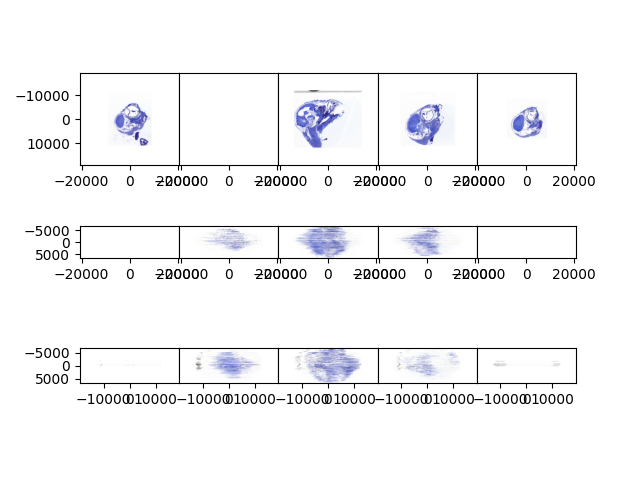

In [15]:
fig,ax = afa.draw(J__,xJ,vmin=0,vmax=1)


# Initialize the atlas


In [16]:
dtype = torch.float64

In [17]:
J = torch.tensor(J__,dtype=dtype).clip(0,1)
xJ = [torch.tensor(x,dtype=dtype) for x in xJ]

I0 = torch.ones(J.shape,dtype=dtype)*0.5 # a reasonable initial guess

I = I0
xI = [x.clone() for x in xJ]
W0 = torch.tensor(W__,dtype=dtype)

(<Figure size 640x480 with 15 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

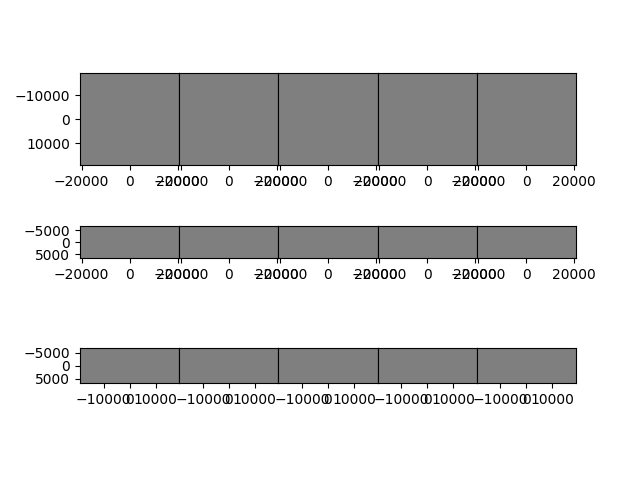

In [18]:
afa.draw(I,xI,vmin=0,vmax=1)

# initialize the parameters


In [19]:
c = 3*0.25**2


p = 1.0

In [20]:
# get the pixel locations
XI = torch.stack(torch.meshgrid(*xI[1:],indexing='ij'),-1)
XJ = torch.stack(torch.meshgrid(*xJ[1:],indexing='ij'),-1)


In [21]:
reload(afa)

<module 'atlas_free_alignment' from '/nfs/data/main/M38/Atlas_free_alignment/atlas_free_alignment.py'>

In [27]:
# before I run this, downsample the image
down = [8,8]
xId,Id = afa.downsample_image_domain(xI,I,[1,down[0],down[1]])
xJd,Jd,W0d = afa.downsample_image_domain(xJ,J,[1,down[0],down[1]],W0,)
# blur J
blur = (0,0,1,1)
Jd = gaussian_filter(Jd*W0d,blur) 
W0db = (gaussian_filter(W0d,blur[1:]))
Jd = Jd / (W0db + 1e-6)
Jd = torch.tensor(Jd,dtype=dtype)
W0d = torch.tensor(W0db,dtype=dtype)
a = 2e2 # make it bigger
a = torch.tensor([2e2*5,2e2,2e2])
Lhatd, LLhatd, Kblurhatd = afa.get_frequency_operators(Id.shape[1:],np.array([x[1] -x[0] for x in xId]),a,p)

In [28]:
niter0 = 2000 # more?
niter_atlas0 = 5 # more than 3
eL0 = 1e-7
eT0 = 1e1

# make them bigger
eL0 = 5e-7 # oscilating, maybe this was too much
eT0 = 2e1

# after downsampling, they need to be bigger
eL0 = 1e-5
eT0 = 5e2

eL0 = 1e-5*5
eT0 = 5e2*2


In [29]:
R = torch.zeros((I0.shape[1],3,3),dtype=dtype)
R[:,:,:] = torch.eye(3,dtype=dtype)[None]
#R[:,:,:] = torch.tensor(A2d0)


In [30]:
Rin = R.clone()
#Rin[Rin.shape[0]//2,1,-1] = -5000 # test

In [31]:
reload(afa)

<module 'atlas_free_alignment' from '/nfs/data/main/M38/Atlas_free_alignment/atlas_free_alignment.py'>

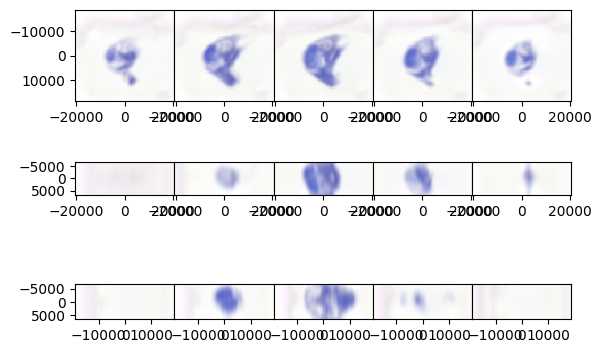

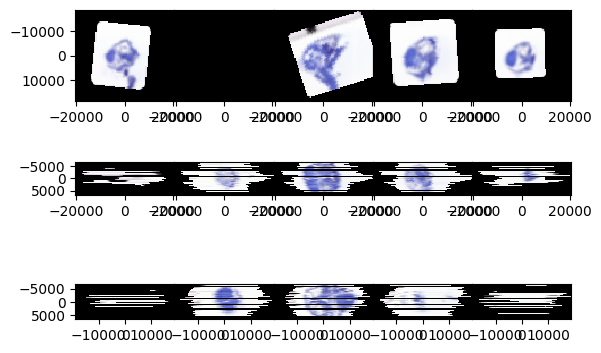

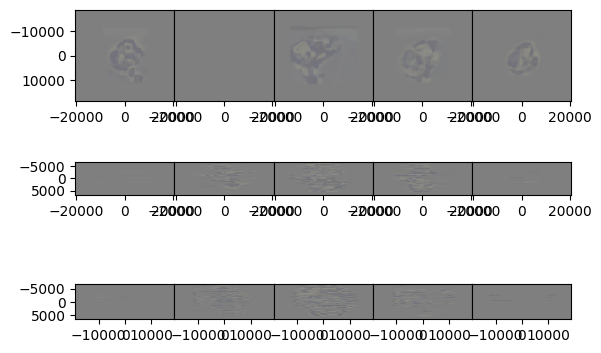

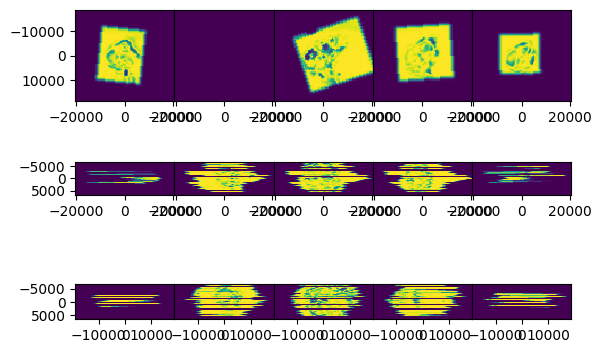

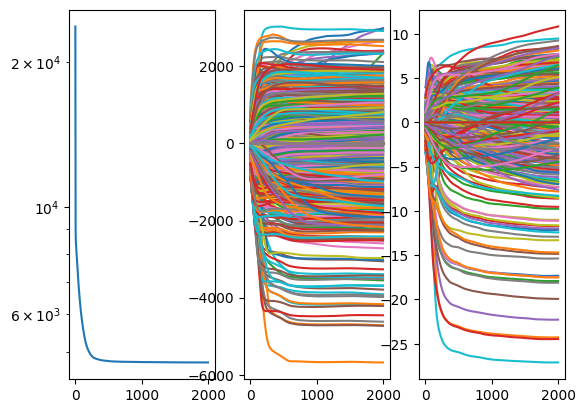

starting it 0
starting it 1
starting it 2
starting it 3
starting it 4
starting it 5
starting it 6
starting it 7
starting it 8
starting it 9
starting it 10
starting it 11
starting it 12
starting it 13
starting it 14
starting it 15
starting it 16
starting it 17
starting it 18
starting it 19
starting it 20
starting it 21
starting it 22
starting it 23
starting it 24
starting it 25
starting it 26
starting it 27
starting it 28
starting it 29
starting it 30
starting it 31
starting it 32
starting it 33
starting it 34
starting it 35
starting it 36
starting it 37
starting it 38
starting it 39
starting it 40
starting it 41
starting it 42
starting it 43
starting it 44
starting it 45
starting it 46
starting it 47
starting it 48
starting it 49
starting it 50
starting it 51
starting it 52
starting it 53
starting it 54
starting it 55
starting it 56
starting it 57
starting it 58
starting it 59
starting it 60
starting it 61
starting it 62
starting it 63
starting it 64
starting it 65
starting it 66
start

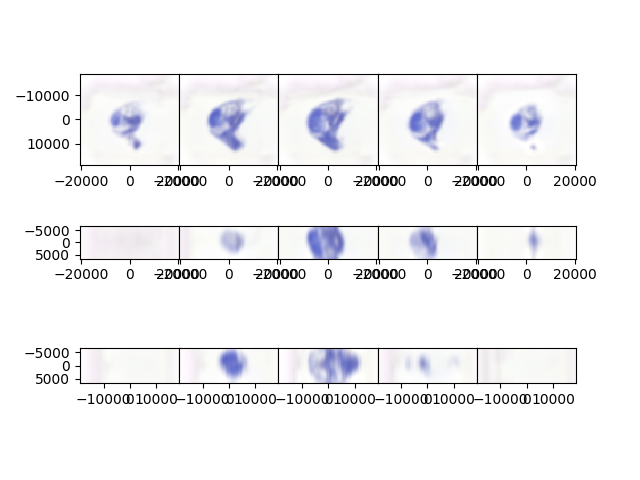

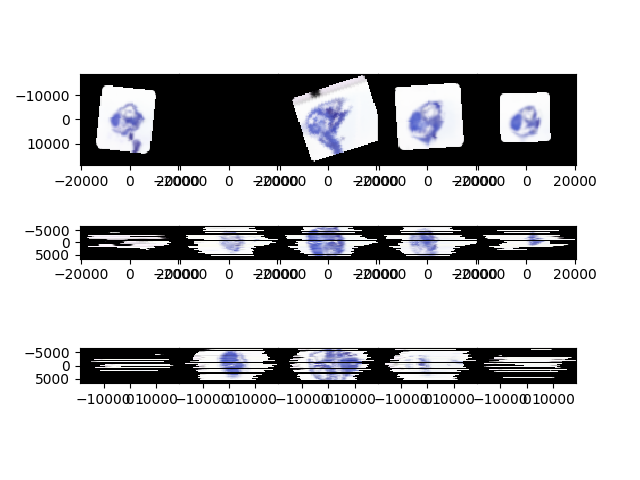

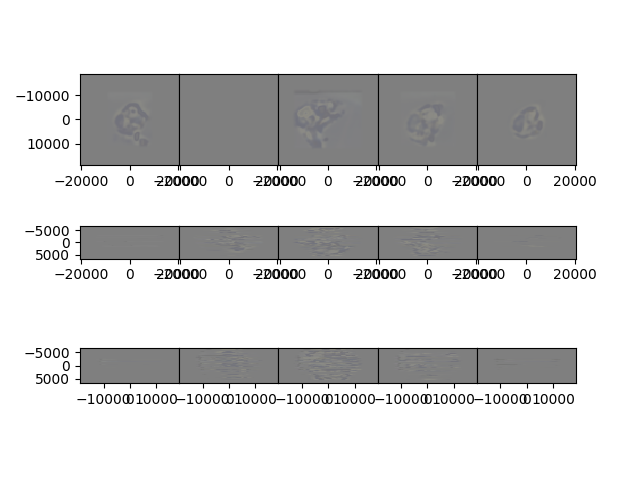

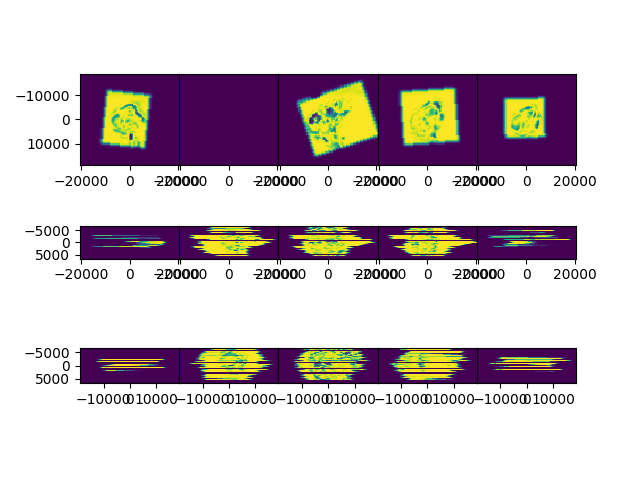

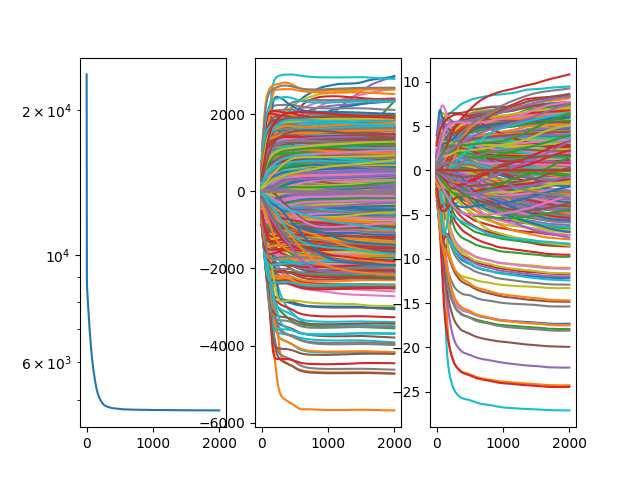

In [33]:
Rout0, Idout0, RiJd, RiWd, RId = afa.atlas_free_alignment(
    xId,Id*0+1,xJd,Jd,W0d,Kblurhatd,
    Rin,
    niter0, niter_atlas0, eL0, eT0, 
    c=c, figprefix='v03_it_00', ndraw=100)

In [34]:
# save the rigid transforms
np.save('v03_rigid_0.npy',Rout0.cpu().numpy())

In [35]:
# can I upsample I? I can use sinc resampling
reload(afa)
I_ = afa.sinc_upsample(Idout0,I.shape[-3:])

(<Figure size 640x480 with 15 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

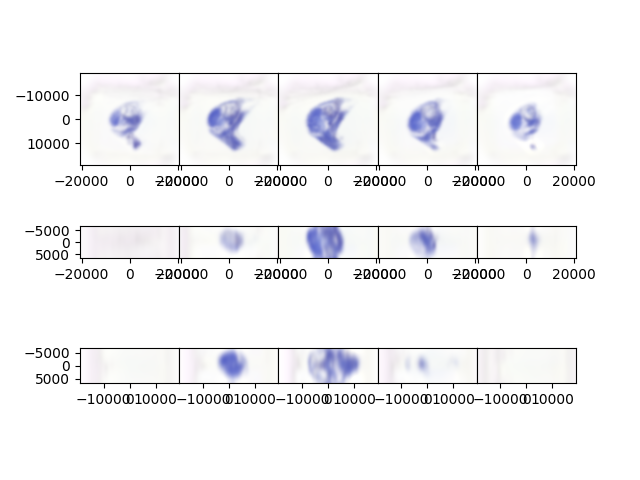

In [36]:
afa.draw(I_,xI,vmin=0,vmax=1)

In [37]:
# before I run this, downsample the image
down = [4,4]
xId,Id = afa.downsample_image_domain(xI,I_,[1,down[0],down[1]])
xJd,Jd,W0d = afa.downsample_image_domain(xJ,J,[1,down[0],down[1]],W0,)
Jd = gaussian_filter(Jd*W0d,blur) 
W0db = (gaussian_filter(W0d,blur[1:]))
Jd = Jd / (W0db + 1e-6)
Jd = torch.tensor(Jd,dtype=dtype)
W0d = torch.tensor(W0db,dtype=dtype)
#a = 1e2 # less smoothing
a = a/2
Lhatd, LLhatd, Kblurhatd = afa.get_frequency_operators(Id.shape[1:],np.array([x[1] -x[0] for x in xId]),a,p)

In [38]:
eL1 = eL0/4 # /2 wasn't enough
eT1 = eT0/4

niter1 = 1000

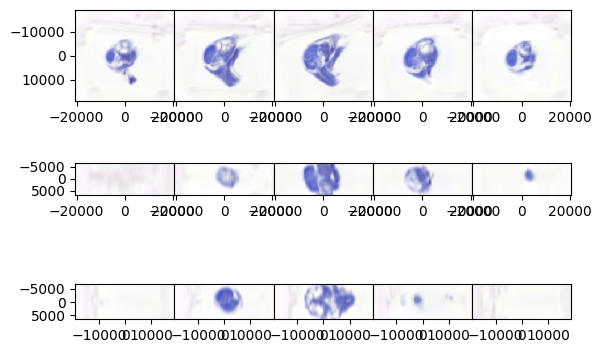

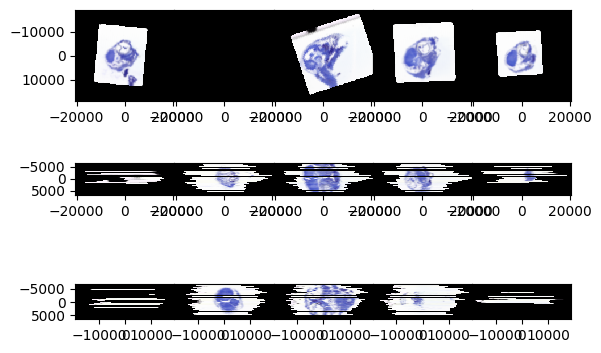

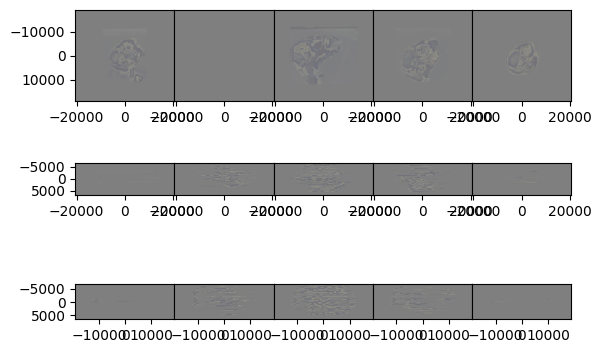

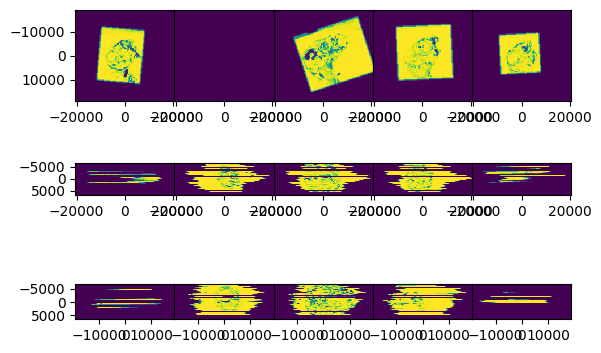

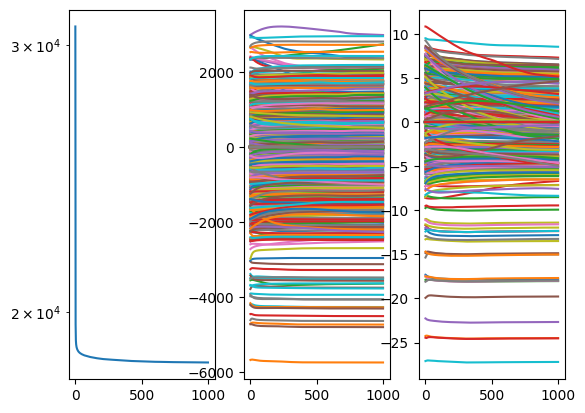

starting it 0
starting it 1
starting it 2
starting it 3
starting it 4
starting it 5
starting it 6
starting it 7
starting it 8
starting it 9
starting it 10
starting it 11
starting it 12
starting it 13
starting it 14
starting it 15
starting it 16
starting it 17
starting it 18
starting it 19
starting it 20
starting it 21
starting it 22
starting it 23
starting it 24
starting it 25
starting it 26
starting it 27
starting it 28
starting it 29
starting it 30
starting it 31
starting it 32
starting it 33
starting it 34
starting it 35
starting it 36
starting it 37
starting it 38
starting it 39
starting it 40
starting it 41
starting it 42
starting it 43
starting it 44
starting it 45
starting it 46
starting it 47
starting it 48
starting it 49
starting it 50
starting it 51
starting it 52
starting it 53
starting it 54
starting it 55
starting it 56
starting it 57
starting it 58
starting it 59
starting it 60
starting it 61
starting it 62
starting it 63
starting it 64
starting it 65
starting it 66
start

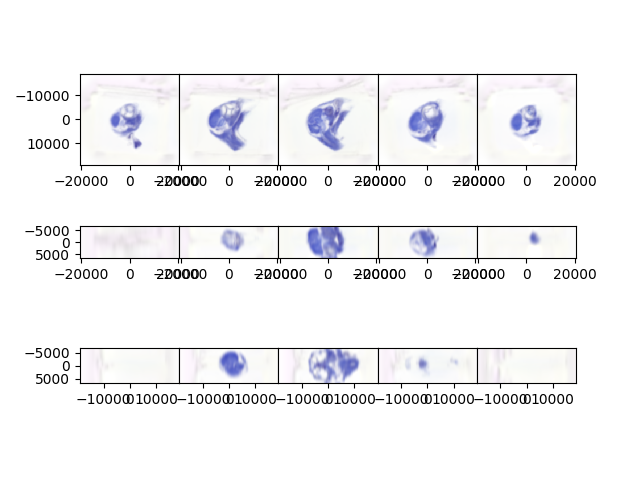

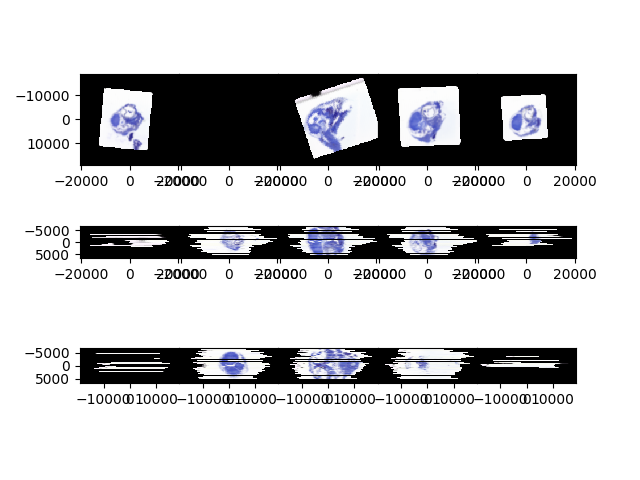

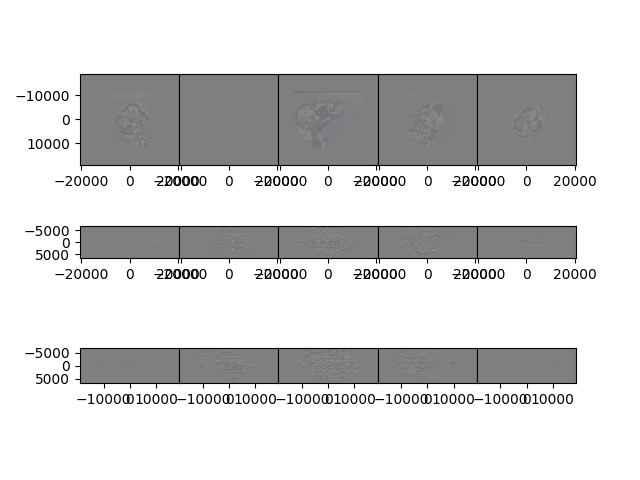

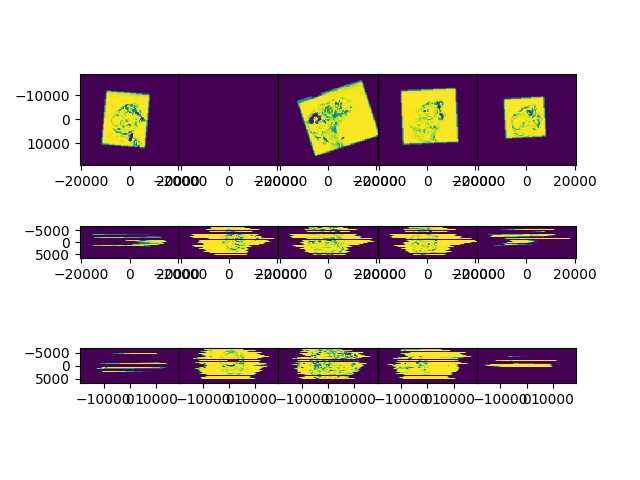

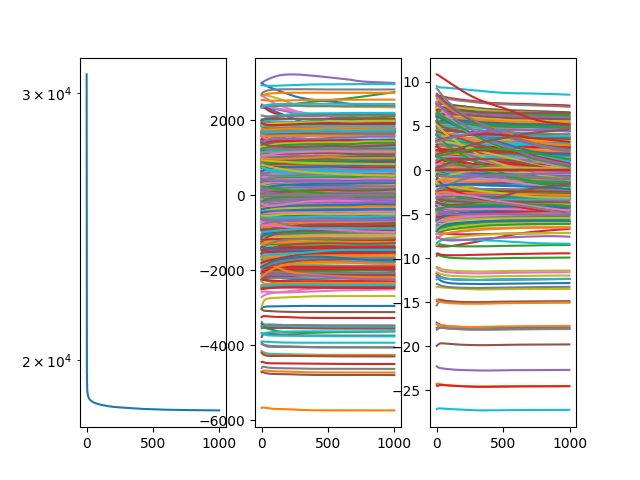

In [39]:
Rout1, Idout1, RiJd, RiWd, RId = afa.atlas_free_alignment(
    xId,Id,xJd,Jd,W0d,Kblurhatd,
    Rout0,
    niter1, niter_atlas0, eL1, eT1, 
    c=c, figprefix='v03_it_01', ndraw=100)

In [40]:
# save the rigid transforms
np.save('v03_rigid_1.npy',Rout1.cpu().numpy())

In [41]:
# upsample with sinc
I_ = afa.sinc_upsample(Idout1,I.shape[-3:])

(<Figure size 640x480 with 15 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

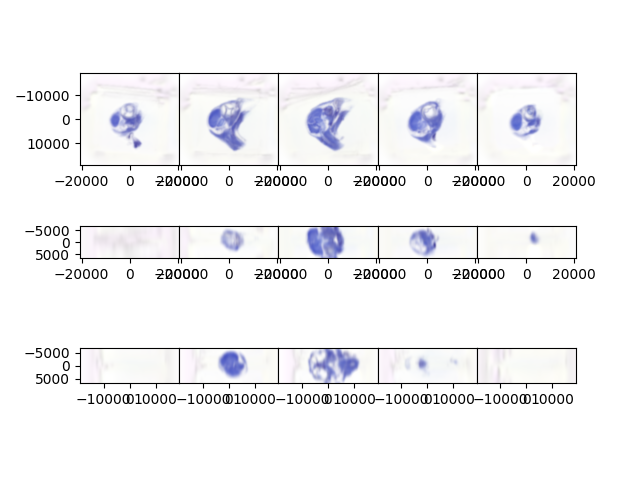

In [42]:
afa.draw(I_,xI,vmin=0,vmax=1)

In [43]:
# before I run this, downsample the image
down = [2,2]
xId,Id = afa.downsample_image_domain(xI,I_,[1,down[0],down[1]])
xJd,Jd,W0d = afa.downsample_image_domain(xJ,J,[1,down[0],down[1]],W0,)
Jd = gaussian_filter(Jd*W0d,blur) 
W0db = (gaussian_filter(W0d,blur[1:]))
Jd = Jd / (W0db + 1e-6)
Jd = torch.tensor(Jd,dtype=dtype)
W0d = torch.tensor(W0db,dtype=dtype)
a = a/2
Lhatd, LLhatd, Kblurhatd = afa.get_frequency_operators(Id.shape[1:],np.array([x[1] -x[0] for x in xId]),a,p)

/tmp/ipykernel_368843/627970123.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig,ax = plt.subplots()


(-0.5, 20.0)

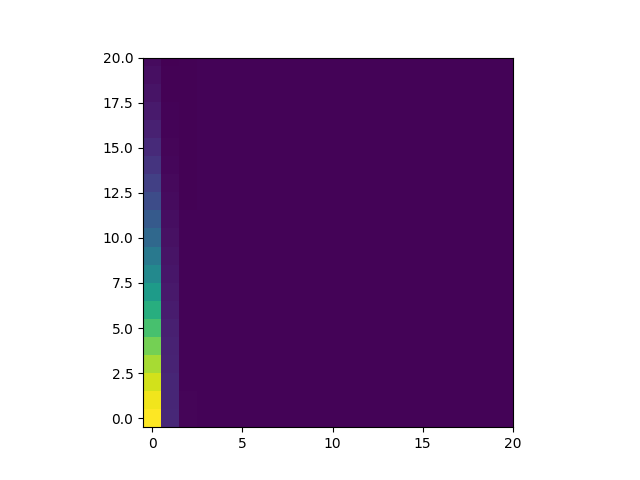

In [44]:
Kblurd = torch.fft.ifftn(Kblurhatd).real
fig,ax = plt.subplots()
ax.imshow(Kblurd[:,0],)
ax.set_xlim((-0.5,20))
ax.set_ylim((-0.5,20))

In [45]:
eL2 = eL0/100 # maybe too big, getting oscilations 
eT2 = eT0/100

niter2 = 500


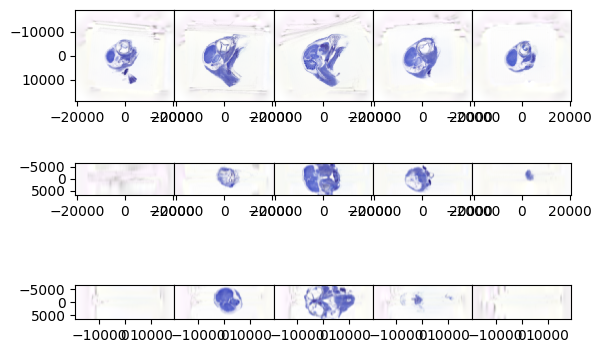

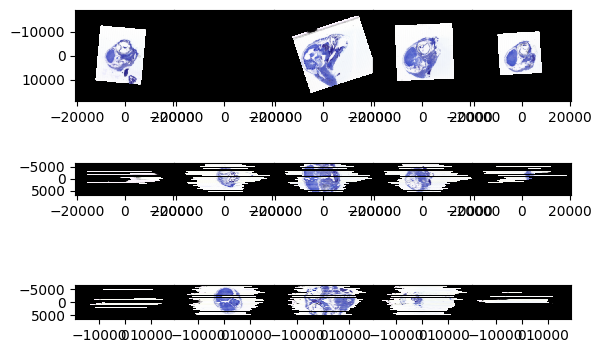

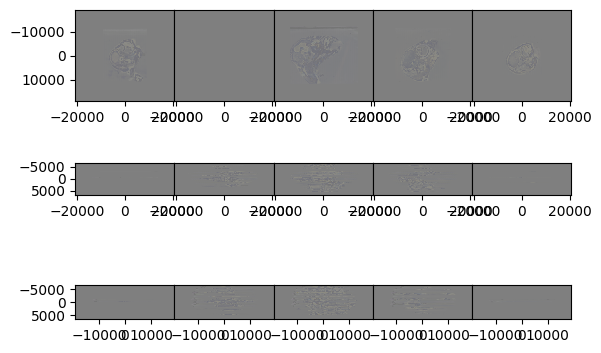

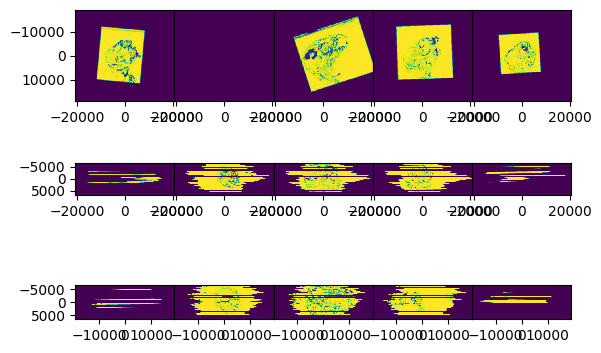

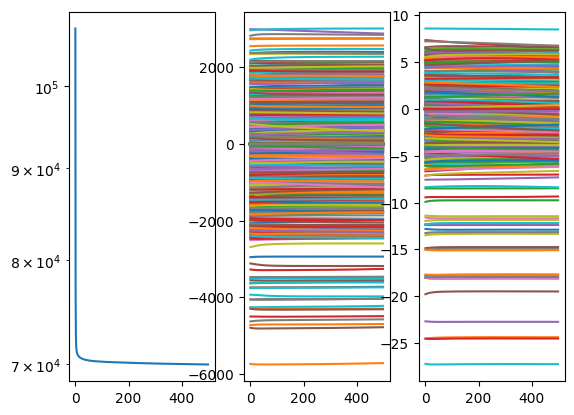

starting it 0
starting it 1
starting it 2
starting it 3
starting it 4
starting it 5
starting it 6
starting it 7
starting it 8
starting it 9
starting it 10
starting it 11
starting it 12
starting it 13
starting it 14
starting it 15
starting it 16
starting it 17
starting it 18
starting it 19
starting it 20
starting it 21
starting it 22
starting it 23
starting it 24
starting it 25
starting it 26
starting it 27
starting it 28
starting it 29
starting it 30
starting it 31
starting it 32
starting it 33
starting it 34
starting it 35
starting it 36
starting it 37
starting it 38
starting it 39
starting it 40
starting it 41
starting it 42
starting it 43
starting it 44
starting it 45
starting it 46
starting it 47
starting it 48
starting it 49
starting it 50
starting it 51
starting it 52
starting it 53
starting it 54
starting it 55
starting it 56
starting it 57
starting it 58
starting it 59
starting it 60
starting it 61
starting it 62
starting it 63
starting it 64
starting it 65
starting it 66
start

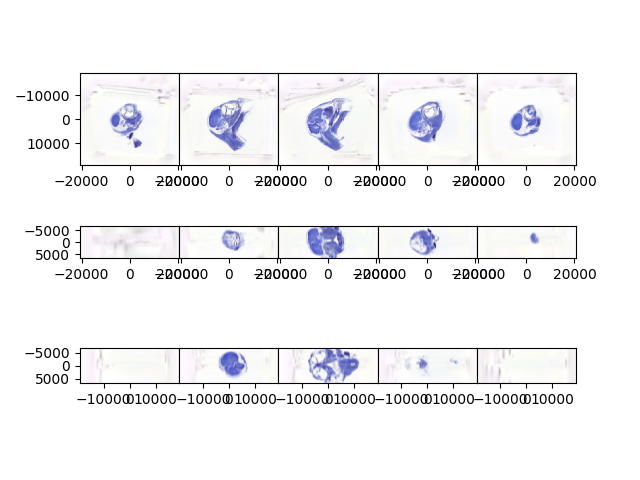

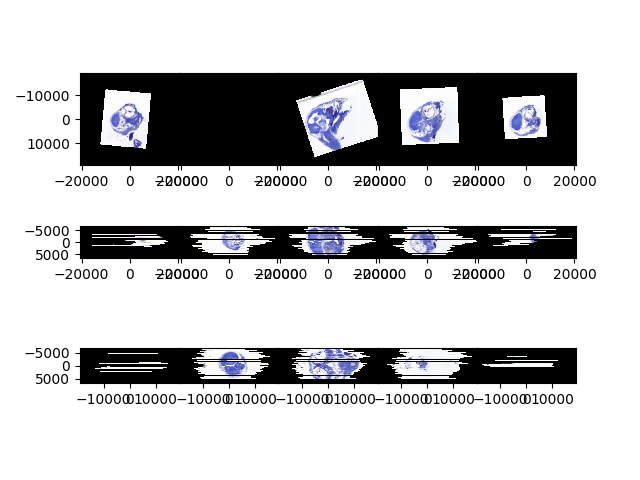

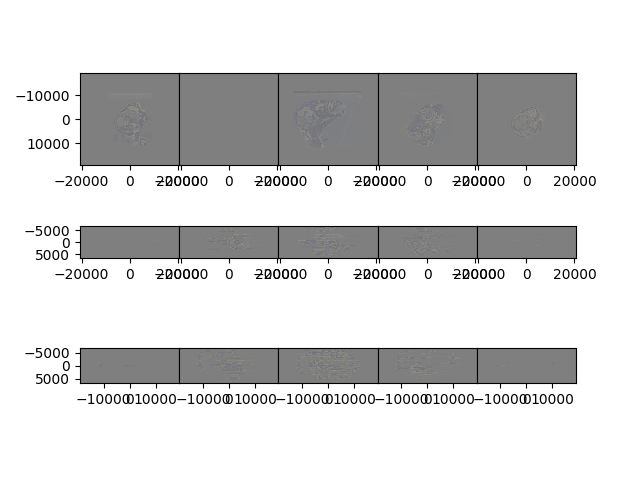

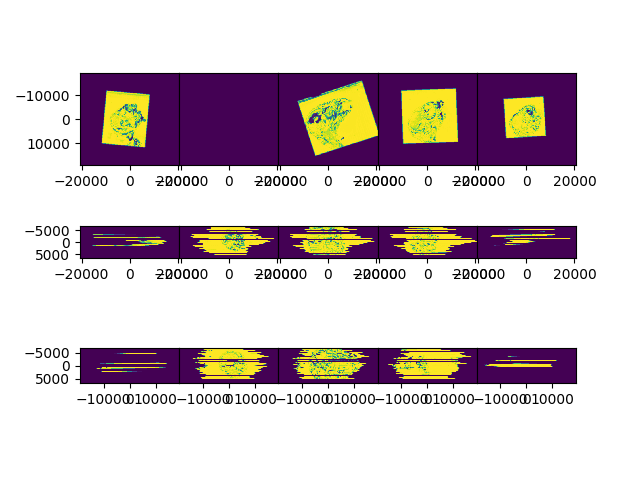

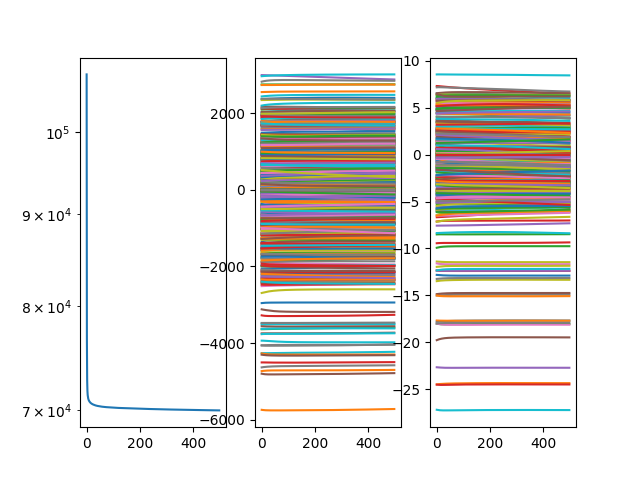

In [46]:
Rout2, Idout2, RiJd, RiWd, RId = afa.atlas_free_alignment(
    xId,Id,xJd,Jd,W0d,Kblurhatd,
    Rout1,
    niter2, niter_atlas0, eL2, eT2, 
    c=c, figprefix='v03_it_02', ndraw=10)

In [47]:
# save the rigid transforms
np.save('v03_rigid_2.npy',Rout2.cpu().numpy())

In [48]:
# last time no downsampling

In [49]:
# upsample with sinc
I_ = afa.sinc_upsample(Idout2,I.shape[-3:])

In [50]:
# before I run this, downsample the image
down = [1,1]
xId,Id = afa.downsample_image_domain(xI,I_,[1,down[0],down[1]])
xJd,Jd,W0d = afa.downsample_image_domain(xJ,J,[1,down[0],down[1]],W0,)
Jd = gaussian_filter(Jd*W0d,blur) 
W0db = (gaussian_filter(W0d,blur[1:]))
Jd = Jd / (W0db + 1e-6)
Jd = torch.tensor(Jd,dtype=dtype)
W0d = torch.tensor(W0db,dtype=dtype)
a = a
Lhatd, LLhatd, Kblurhatd = afa.get_frequency_operators(Id.shape[1:],np.array([x[1] -x[0] for x in xId]),a,p)

In [51]:
eL3 = eL0/500
eT3 = eT0/500

niter3 = 200

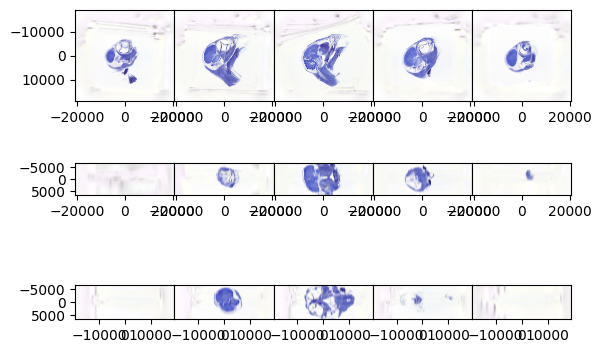

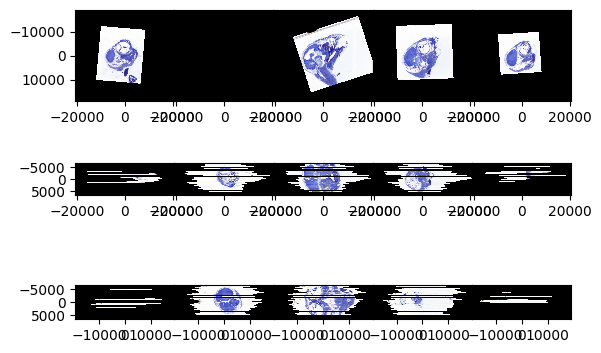

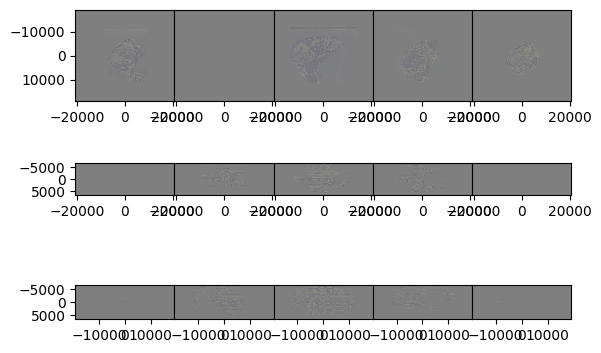

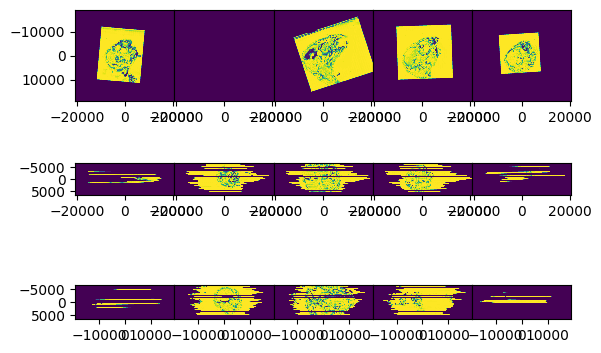

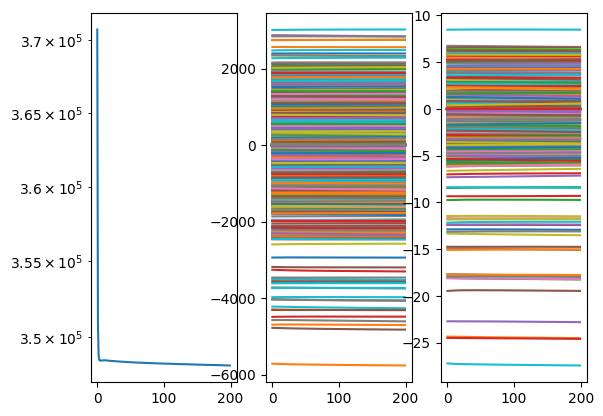

starting it 0
starting it 1
starting it 2
starting it 3
starting it 4
starting it 5
starting it 6
starting it 7
starting it 8
starting it 9
starting it 10
starting it 11
starting it 12
starting it 13
starting it 14
starting it 15
starting it 16
starting it 17
starting it 18
starting it 19
starting it 20
starting it 21
starting it 22
starting it 23
starting it 24
starting it 25
starting it 26
starting it 27
starting it 28
starting it 29
starting it 30
starting it 31
starting it 32
starting it 33
starting it 34
starting it 35
starting it 36
starting it 37
starting it 38
starting it 39
starting it 40
starting it 41
starting it 42
starting it 43
starting it 44
starting it 45
starting it 46
starting it 47
starting it 48
starting it 49
starting it 50
starting it 51
starting it 52
starting it 53
starting it 54
starting it 55
starting it 56
starting it 57
starting it 58
starting it 59
starting it 60
starting it 61
starting it 62
starting it 63
starting it 64
starting it 65
starting it 66
start

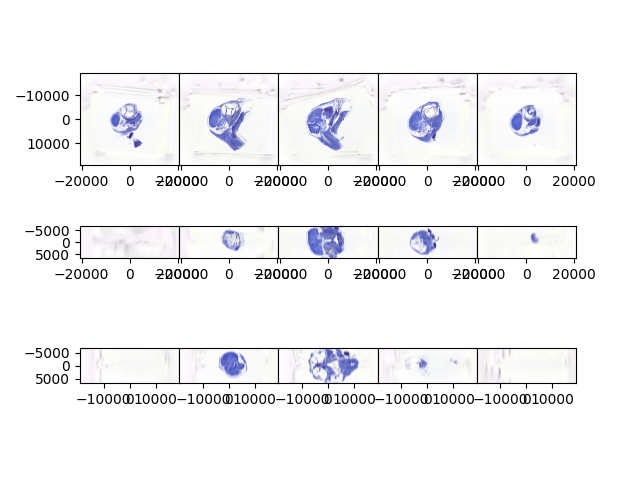

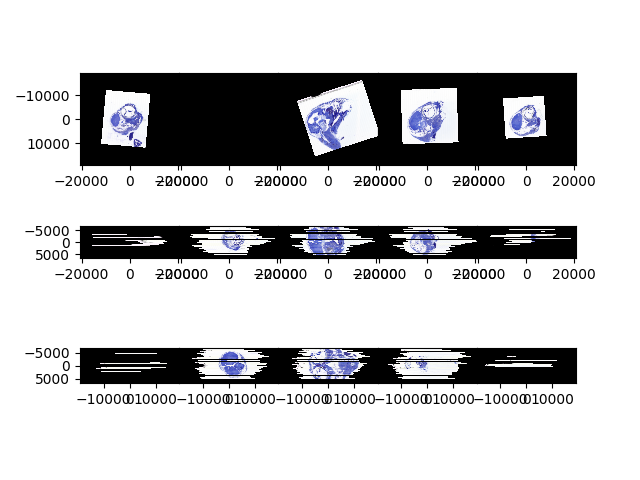

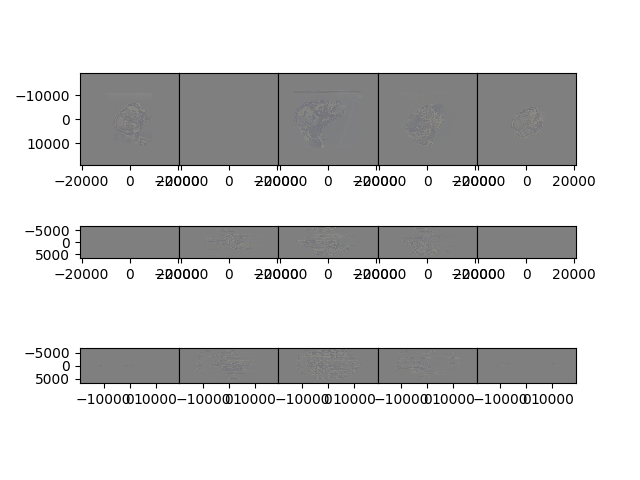

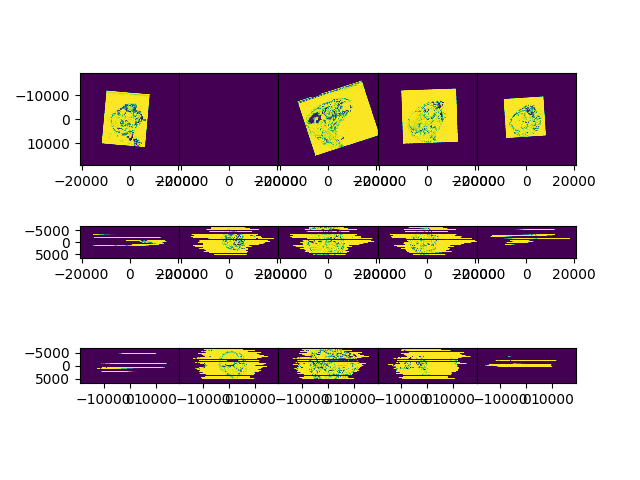

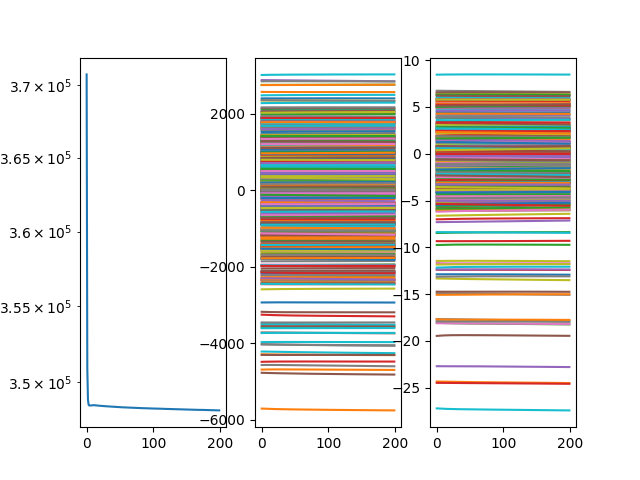

In [52]:
Rout3, Idout3, RiJd, RiWd, RId = afa.atlas_free_alignment(
    xId,Id,xJd,Jd,W0d,Kblurhatd,
    Rout2,
    niter3, niter_atlas0, eL3, eT3, 
    c=c, figprefix='v03_it_03', ndraw=10)

In [53]:
# let's write it out


In [54]:
import nibabel as nib
dI = np.array([x[1] - x[0] for x in xI])
affine = np.diag(dI.tolist()+[1])
affine[:3,-1] = np.array([x[0] for x in xI])

vol = nib.Nifti1Image((Idout3.permute(1,2,3,0).cpu().numpy()*256).clip(0,255).astype(np.uint8),affine)


In [55]:
# save the rigid transforms
np.save('v03_rigid_3.npy',Rout2.cpu().numpy())

In [57]:

# save it
nib.save(vol,'finch_test_03.nii.gz')

In [58]:
vol.shape

(335, 651, 704, 3)